<a href="https://colab.research.google.com/github/saifulroni/clusters_data/blob/main/Clustering_liver_patient_processed_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

K-means

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Large_Scale_Implementation_of_DSK_Chain/refs/heads/main/Cleaned_Data/liver_patient_processed_data.csv'
df = pd.read_csv(url)
df.head()

,Age,Total_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset,Gender_Male
0,65,0.7,187,16,18,6.8,3.3,0.90,1,0
1,62,10.9,699,64,100,7.5,3.2,0.74,1,1
2,62,7.3,490,60,68,7.0,3.3,0.89,1,1
3,58,1.0,182,14,20,6.8,3.4,1.00,1,1
4,72,3.9,195,27,59,7.3,2.4,0.40,1,1


In [ ]:
df['Dataset'] = df['Dataset'].replace({1: 0, 2: 1})
display(df.head())

,Age,Total_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset,Gender_Male
0,65,0.7,187,16,18,6.8,3.3,0.90,0,0
1,62,10.9,699,64,100,7.5,3.2,0.74,0,1
2,62,7.3,490,60,68,7.0,3.3,0.89,0,1
3,58,1.0,182,14,20,6.8,3.4,1.00,0,1
4,72,3.9,195,27,59,7.3,2.4,0.40,0,1


In [ ]:
X = df.drop(columns=['Dataset'])
y = df['Dataset']

X_0 = X[y == 0]
X_1 = X[y == 1]

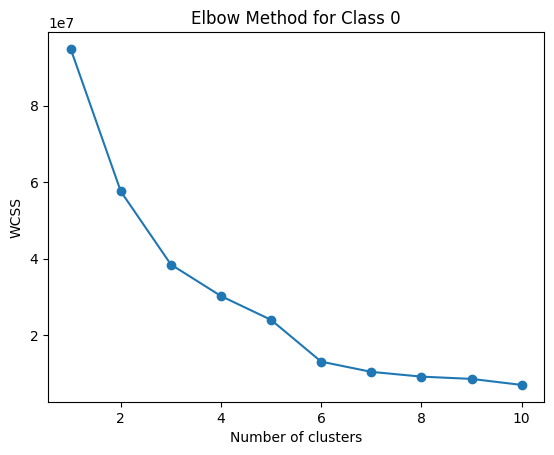

In [ ]:
wcss_0 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_0)
    wcss_0.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_0, marker='o')
plt.title('Elbow Method for Class 0')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

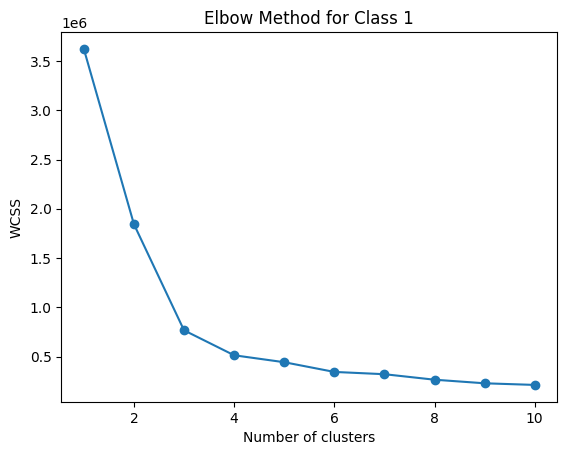

In [ ]:
wcss_1 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_1)
    wcss_1.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_1, marker='o')
plt.title('Elbow Method for Class 1')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
n_clusters_0 = 3   # <-- set based on elbow visualization
n_clusters_1 = 3   # <-- set based on elbow visualization

kmeans_0 = KMeans(n_clusters=n_clusters_0, random_state=42, n_init=10)
sub_labels_0 = kmeans_0.fit_predict(X_0)

kmeans_1 = KMeans(n_clusters=n_clusters_1, random_state=42, n_init=10)
sub_labels_1 = kmeans_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 365 samples
Class 0 - Cluster 1: 7 samples
Class 0 - Cluster 2: 34 samples


In [ ]:
counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 1 - Cluster 0: 150 samples
Class 1 - Cluster 1: 1 samples
Class 1 - Cluster 2: 13 samples


DBSCAN

In [ ]:
dbscan_0 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_0 = dbscan_0.fit_predict(X_0)

dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_1 = dbscan_1.fit_predict(X_1)

In [ ]:
unique_0, counts_0 = np.unique(sub_labels_0, return_counts=True)
for cluster, count in zip(unique_0, counts_0):
    print(f"Class 0 - Cluster {cluster}: {count} samples")

Class 0 - Cluster -1: 406 samples


In [ ]:

unique_1, counts_1 = np.unique(sub_labels_1, return_counts=True)
for cluster, count in zip(unique_1, counts_1):
    print(f"Class 1 - Cluster {cluster}: {count} samples")

Class 1 - Cluster -1: 164 samples


Hierarchical Clustering

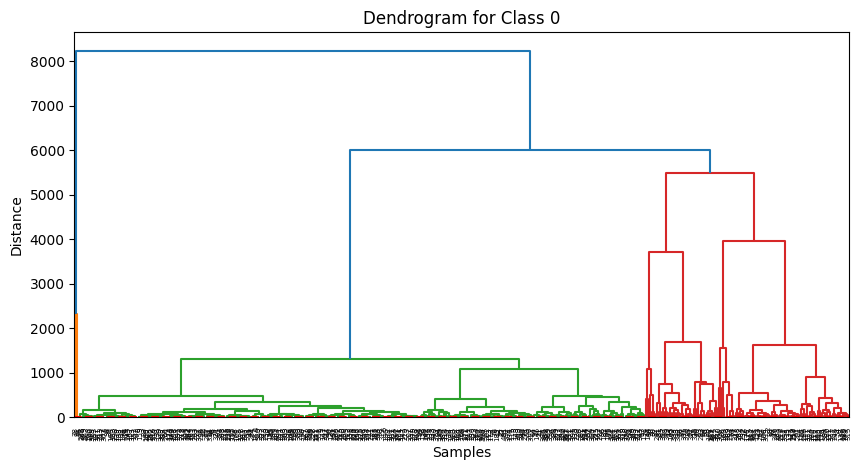

In [ ]:
# Generate linkage matrix for Class 0
Z = linkage(X_0, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 0")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_0, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 1


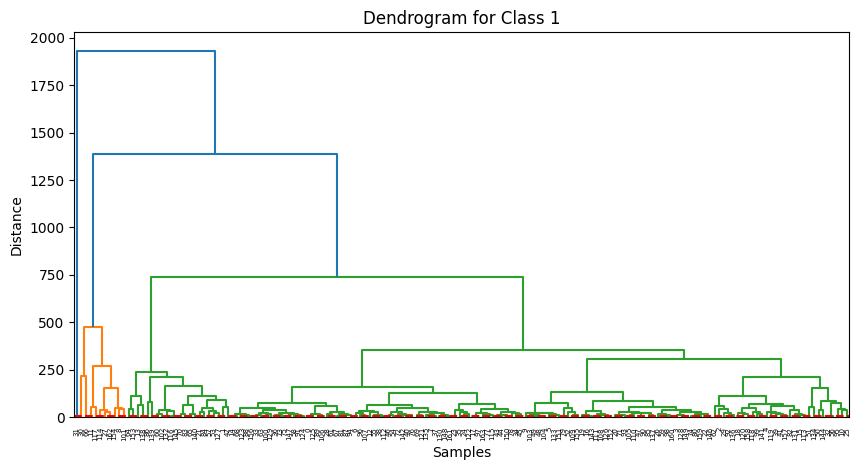

In [ ]:
# Generate linkage matrix for Class 0
Z = linkage(X_1, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 1")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_1, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 1


second method

In [ ]:
hc_0 = AgglomerativeClustering(n_clusters=2, linkage='ward')
sub_labels_0 = hc_0.fit_predict(X_0)

hc_1 = AgglomerativeClustering(n_clusters=2, linkage='ward')
sub_labels_1 = hc_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 404 samples
Class 0 - Cluster 1: 2 samples
Class 1 - Cluster 0: 163 samples
Class 1 - Cluster 1: 1 samples


Spectral Clustering

In [ ]:
def run_spectral_clustering(X_data, class_label):
    best_score = -1
    best_k = None
    best_labels = None

    # Search for the best number of clusters
    for k in range(2, 7):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',  # or 'rbf'
            assign_labels='kmeans',
            random_state=42
        )
        labels = sc.fit_predict(X_data)
        # Check if more than one cluster is found before calculating silhouette score
        if len(np.unique(labels)) > 1:
            score = silhouette_score(X_data, labels)
            print(f"Class {class_label} | n_clusters={k}, Silhouette Score={score:.4f}")

            if score > best_score:
                best_score = score
                best_k = k
                best_labels = labels
        else:
            print(f"Class {class_label} | n_clusters={k}, Only one cluster found. Skipping silhouette score.")


    print(f"Best n_clusters for Class {class_label}: {best_k} (Silhouette Score={best_score:.4f})")
    return best_labels, best_k, best_score

In [ ]:
# ---- Run Spectral Clustering with automatic k selection ----
sub_labels_0, best_k_0, best_score_0 = run_spectral_clustering(X_0, class_label=0)
sub_labels_1, best_k_1, best_score_1 = run_spectral_clustering(X_1, class_label=1)

Class 0 | n_clusters=2, Silhouette Score=0.5564
Class 0 | n_clusters=3, Silhouette Score=0.5257
Class 0 | n_clusters=4, Silhouette Score=0.2835
Class 0 | n_clusters=5, Silhouette Score=0.3084
Class 0 | n_clusters=6, Silhouette Score=0.3289
Best n_clusters for Class 0: 2 (Silhouette Score=0.5564)
Class 1 | n_clusters=2, Silhouette Score=0.6242
Class 1 | n_clusters=3, Silhouette Score=0.2012
Class 1 | n_clusters=4, Silhouette Score=0.1587
Class 1 | n_clusters=5, Silhouette Score=0.1511
Class 1 | n_clusters=6, Silhouette Score=0.1208
Best n_clusters for Class 1: 2 (Silhouette Score=0.6242)


In [ ]:
# Show cluster counts
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 109 samples
Class 0 - Cluster 1: 297 samples
Class 1 - Cluster 0: 133 samples
Class 1 - Cluster 1: 31 samples


***recluster

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ===============================
# STEP 0: Prepare your data
# ===============================
X = X.copy()  # Replace with your DataFrame
y = y.copy()       # 0/1 labels for classes
target_name = 'Dataset'        # adjust if needed

# ===============================
# STEP 1: Scale features
# ===============================
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# ===============================
# STEP 2: Class-wise clustering
# ===============================
def balanced_kmeans(X_data, class_label, k_range=(2,7)):
    """
    KMeans with automatic k selection based on silhouette score.
    Encourages roughly balanced clusters but does not force exact parity.
    """
    best_score = -1
    best_k = None
    best_labels = None

    for k in range(*k_range):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_data)
        score = silhouette_score(X_data, labels)

        # Compute balance ratio
        counts = np.bincount(labels)
        balance_ratio = min(counts) / max(counts)
        composite_score = score * balance_ratio  # Encourage balanced clusters

        print(f"Class {class_label} | k={k} | Silhouette={score:.4f} | Balance Ratio={balance_ratio:.3f}")

        if composite_score > best_score:
            best_score = composite_score
            best_k = k
            best_labels = labels

    print(f"✅ Best k for Class {class_label}: {best_k} | Composite Score={best_score:.4f}\n")
    return best_labels, best_k

# Separate features by class
X0_scaled = X_scaled[y==0]
X1_scaled = X_scaled[y==1]

# Run clustering for each class
labels_0, k0 = balanced_kmeans(X0_scaled, class_label=0)
labels_1, k1 = balanced_kmeans(X1_scaled, class_label=1)

# ===============================
# STEP 3: Map cluster labels back to original data
# ===============================
final_df = X.copy()

# Offset class 1 clusters so IDs are unique
offset = max(labels_0) + 1
cluster_labels = pd.Series(index=X.index, dtype=int)
cluster_labels.loc[y==0] = labels_0
cluster_labels.loc[y==1] = labels_1 + offset
final_df['Cluster_Label'] = cluster_labels.astype(int)

# ===============================
# STEP 4: Save final clustered data
# ===============================
final_df.to_csv('Clustered_liver_patient_processed_data.csv', index=False)
print("✅ Clustered data saved successfully as 'Clustered_liver_patient_processed_data.csv'")

# ===============================
# STEP 5: Optional cluster summary
# ===============================
def show_cluster_counts(labels, class_label):
    counts = np.bincount(labels)
    total = counts.sum()
    print(f"\n=== Cluster Distribution for Class {class_label} ===")
    for i, count in enumerate(counts):
        pct = (count / total) * 100
        print(f"Cluster {i}: {count} samples ({pct:.2f}%)")
    print(f"Total Samples: {total}")
    print(f"Max-Min Difference: {counts.max() - counts.min()}")
    print(f"Balance Ratio (min/max): {counts.min() / counts.max():.3f}\n")

show_cluster_counts(labels_0, 0)
show_cluster_counts(labels_1, 1)

Class 0 | k=2 | Silhouette=0.6211 | Balance Ratio=0.025
Class 0 | k=3 | Silhouette=0.2025 | Balance Ratio=0.046
Class 0 | k=4 | Silhouette=0.2037 | Balance Ratio=0.045
Class 0 | k=5 | Silhouette=0.2218 | Balance Ratio=0.051
Class 0 | k=6 | Silhouette=0.2344 | Balance Ratio=0.051
✅ Best k for Class 0: 2 | Composite Score=0.0157

Class 1 | k=2 | Silhouette=0.2579 | Balance Ratio=0.929
Class 1 | k=3 | Silhouette=0.2607 | Balance Ratio=0.522
Class 1 | k=4 | Silhouette=0.2455 | Balance Ratio=0.714
Class 1 | k=5 | Silhouette=0.2782 | Balance Ratio=0.477
Class 1 | k=6 | Silhouette=0.2806 | Balance Ratio=0.178
✅ Best k for Class 1: 2 | Composite Score=0.2397

✅ Clustered data saved successfully as 'Clustered_liver_patient_processed_data.csv'

=== Cluster Distribution for Class 0 ===
Cluster 0: 396 samples (97.54%)
Cluster 1: 10 samples (2.46%)
Total Samples: 406
Max-Min Difference: 386
Balance Ratio (min/max): 0.025


=== Cluster Distribution for Class 1 ===
Cluster 0: 79 samples (48.17%)
Clus

2.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

# ---- STEP 1: Function for spectral clustering with silhouette selection ----
def run_spectral_clustering(X_data, class_label, k_range=(2,7)):
    best_score = -1
    best_k = None
    best_labels = None

    for k in range(*k_range):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',
            assign_labels='kmeans',
            random_state=42
        )
        labels = sc.fit_predict(X_data)

        if len(np.unique(labels)) > 1:
            score = silhouette_score(X_data, labels)
            print(f"Class {class_label} | k={k}, Silhouette={score:.4f}")
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = labels
        else:
            print(f"Class {class_label} | k={k} → only one cluster found.")
    print(f"✅ Best k for Class {class_label}: {best_k} (Score={best_score:.4f})\n")
    return best_labels, best_k


# ---- STEP 2: Reclustering large clusters ----
def recluster_large_groups(X_data, labels, class_label, size_threshold=0.8, recluster_k=3):
    """
    Recluster the largest cluster if it holds more than 'size_threshold' proportion of samples.
    """
    counts = np.bincount(labels)
    total = len(labels)
    largest_cluster = np.argmax(counts)
    largest_ratio = counts[largest_cluster] / total

    print(f"Class {class_label} - Largest cluster = {largest_cluster} ({largest_ratio*100:.2f}% of data)")

    new_labels = labels.copy()
    offset = labels.max() + 1  # ensure new labels don't overlap

    if largest_ratio > size_threshold:
        # Extract subset to recluster
        idx_large = np.where(labels == largest_cluster)[0]
        X_large = X_data.iloc[idx_large]

        print(f"➡ Reclustering large cluster (size={len(X_large)}) into {recluster_k} subclusters...")
        sc = SpectralClustering(
            n_clusters=recluster_k,
            affinity='nearest_neighbors',
            assign_labels='kmeans',
            random_state=42
        )
        sub_labels = sc.fit_predict(X_large)
        new_labels[idx_large] = sub_labels + offset  # assign new unique labels

        print(f"✅ Reclustering done. Total clusters now: {new_labels.max()+1}")

    return new_labels


# ---- STEP 3: Combine process ----
def run_balanced_spectral(X_data, class_label):
    labels, best_k = run_spectral_clustering(X_data, class_label)
    new_labels = recluster_large_groups(X_data, labels, class_label)
    return new_labels


# ---- STEP 4: Apply to your data ----
# Example:
sub_labels_0 = run_balanced_spectral(X_0, class_label=0)
sub_labels_1 = run_balanced_spectral(X_1, class_label=1)


# ---- STEP 5: Show cluster distributions ----
def show_cluster_counts(labels, class_label):
    counts = np.bincount(labels)
    total = counts.sum()
    print(f"\n=== Cluster Distribution for Class {class_label} ===")
    for i, count in enumerate(counts):
        pct = (count / total) * 100
        print(f"Cluster {i}: {count} samples ({pct:.2f}%)")
    print(f"Total: {total}")
    print(f"Balance Ratio: {counts.min()/counts.max():.3f}\n")

show_cluster_counts(sub_labels_0, 0)
show_cluster_counts(sub_labels_1, 1)

Class 0 | k=2, Silhouette=0.5564
Class 0 | k=3, Silhouette=0.5257
Class 0 | k=4, Silhouette=0.2835
Class 0 | k=5, Silhouette=0.3084
Class 0 | k=6, Silhouette=0.3289
✅ Best k for Class 0: 2 (Score=0.5564)

Class 0 - Largest cluster = 1 (73.15% of data)
Class 1 | k=2, Silhouette=0.6242
Class 1 | k=3, Silhouette=0.2012
Class 1 | k=4, Silhouette=0.1587
Class 1 | k=5, Silhouette=0.1511
Class 1 | k=6, Silhouette=0.1208
✅ Best k for Class 1: 2 (Score=0.6242)

Class 1 - Largest cluster = 0 (81.10% of data)
➡ Reclustering large cluster (size=133) into 3 subclusters...
✅ Reclustering done. Total clusters now: 5

=== Cluster Distribution for Class 0 ===
Cluster 0: 109 samples (26.85%)
Cluster 1: 297 samples (73.15%)
Total: 406
Balance Ratio: 0.367


=== Cluster Distribution for Class 1 ===
Cluster 0: 0 samples (0.00%)
Cluster 1: 31 samples (18.90%)
Cluster 2: 49 samples (29.88%)
Cluster 3: 42 samples (25.61%)
Cluster 4: 42 samples (25.61%)
Total: 164
Balance Ratio: 0.000



In [ ]:
import numpy as np

# Remove labels that have no samples
unique_labels = np.unique(sub_labels_1)
valid_labels = [l for l in unique_labels if np.sum(sub_labels_1 == l) > 0]

print("Valid clusters:", valid_labels)

Valid clusters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


In [ ]:
import numpy as np
import pandas as pd

# --- Step 1: Relabel clusters to remove empty ones ---
def relabel_clusters(labels):
    """Reindex cluster labels (remove gaps and empty clusters)."""
    unique_labels = sorted([l for l in np.unique(labels) if np.sum(labels == l) > 0])
    label_map = {old: new for new, old in enumerate(unique_labels)}
    new_labels = np.array([label_map[l] for l in labels])
    return new_labels

# Apply relabeling
sub_labels_0 = relabel_clusters(sub_labels_0)
sub_labels_1 = relabel_clusters(sub_labels_1)

# --- Step 2: Merge both class-wise clusters into one DataFrame ---
df_0 = X_0.copy()
df_0['Class'] = 0
df_0['Cluster_Label'] = sub_labels_0

df_1 = X_1.copy()
df_1['Class'] = 1
df_1['Cluster_Label'] = sub_labels_1

# Combine both datasets
final_df = pd.concat([df_0, df_1], ignore_index=True)

# --- Step 3: Create continuous cluster numbering across both classes ---
# Example: class 0 clusters 0–3 → class 1 clusters start from 4
offset = final_df.loc[final_df['Class'] == 0, 'Cluster_Label'].max() + 1
final_df.loc[final_df['Class'] == 1, 'Cluster_Label'] += offset

# --- Step 4: Drop class column if you don't want it in the final CSV ---
final_df = final_df.drop(columns=['Class'])

# --- Step 5: Save to CSV ---
final_df.to_csv("Clustered_liver_patient_processed_data.csv", index=False)
print("✅ Clustered data saved successfully as 'Clustered_liver_patient_processed_data.csv'")

# --- Step 6: Optional summary ---
def show_cluster_counts(df):
    counts = df['Cluster_Label'].value_counts().sort_index()
    total = counts.sum()
    print("\n=== Final Cluster Distribution ===")
    for c, count in counts.items():
        pct = (count / total) * 100
        print(f"Cluster {c}: {count} samples ({pct:.2f}%)")
    print(f"Total Samples: {total}")
    print(f"Clusters: {len(counts)}\n")

show_cluster_counts(final_df)


✅ Clustered data saved successfully as 'Clustered_liver_patient_processed_data.csv'

=== Final Cluster Distribution ===
Cluster 0: 109 samples (19.12%)
Cluster 1: 297 samples (52.11%)
Cluster 2: 31 samples (5.44%)
Cluster 3: 49 samples (8.60%)
Cluster 4: 42 samples (7.37%)
Cluster 5: 42 samples (7.37%)
Total Samples: 570
Clusters: 6



In [ ]:
clustered_df = pd.read_csv('Clustered_liver_patient_processed_data.csv')
display(clustered_df.head())

,Age,Total_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Gender_Male,Cluster_Label
0,65,0.7,187,16,18,6.8,3.3,0.90,0,1
1,62,10.9,699,64,100,7.5,3.2,0.74,1,0
2,62,7.3,490,60,68,7.0,3.3,0.89,1,0
3,58,1.0,182,14,20,6.8,3.4,1.00,1,1
4,72,3.9,195,27,59,7.3,2.4,0.40,1,1


In [ ]:
clustered_df_renamed = clustered_df.rename(columns={'Cluster_Label': 'Dataset'})
clustered_df_renamed.to_csv('Clustered_liver_patient_processed_data_renamed.csv', index=False)
print("Column 'Cluster_Label' renamed to 'Dataset' and saved to 'Clustered_liver_patient_processed_data_renamed.csv'")

Column 'Cluster_Label' renamed to 'Dataset' and saved to 'Clustered_liver_patient_processed_data_renamed.csv'


MiniBatchKMeans


In [ ]:
n_clusters_0 = 3
mbk_0 = MiniBatchKMeans(
    n_clusters=n_clusters_0,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_0 = mbk_0.fit_predict(X_0)

n_clusters_1 = 3
mbk_1 = MiniBatchKMeans(
    n_clusters=n_clusters_1,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_1 = mbk_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 379 samples
Class 0 - Cluster 1: 5 samples
Class 0 - Cluster 2: 22 samples
Class 1 - Cluster 0: 8 samples
Class 1 - Cluster 1: 130 samples
Class 1 - Cluster 2: 26 samples


reclustering

In [ ]:
def run_spectral_clustering(X_data, class_label=None, forced_k=None, k_range=(2, 7)):
    """
    Run spectral clustering trying k in range(k_range) (k_range end exclusive).
    If forced_k is provided and in tested ks, returns labels for forced_k.
    Returns: labels (np.array, indexed like X_data), chosen_k, score_for_chosen_k, scores_dict
    """
    all_scores = {}
    best_k = None
    best_score = -np.inf
    best_labels = None

    ks = list(range(k_range[0], k_range[1]))
    for k in ks:
        sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels) if len(np.unique(labels)) > 1 else -1
        all_scores[k] = score
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
        print(f"[{class_label}] k={k} -> silhouette={score:.4f}")

    # If forced_k requested and valid, recompute labels for forced_k
    if forced_k is not None:
        if forced_k not in all_scores:
            raise ValueError(f"forced_k {forced_k} not in tested ks {ks}")
        print(f"[{class_label}] Using forced_k={forced_k} (silhouette={all_scores[forced_k]:.4f})")
        sc = SpectralClustering(n_clusters=forced_k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        forced_labels = sc.fit_predict(X_data)
        return forced_labels, forced_k, all_scores[forced_k], all_scores

    return best_labels, best_k, best_score, all_scores


def initial_cluster_by_class(X, y, k_range=(2,7)):
    """
    Cluster data separately for each distinct class in y.
    Returns dict: class_label -> pd.Series(labels, index = X_class.index)
    Also returns dicts for chosen k and scores.
    """
    labels_by_class = {}
    best_k_by_class = {}
    score_by_class = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        labels, chosen_k, best_score, scores = run_spectral_clustering(X_cls, class_label=cls, k_range=k_range)
        labels_by_class[cls] = pd.Series(labels, index=X_cls.index)
        best_k_by_class[cls] = chosen_k
        score_by_class[cls] = best_score
    return labels_by_class, best_k_by_class, score_by_class


def get_cluster_counts(labels_by_class):
    """
    labels_by_class: dict from class_label -> pd.Series(labels, index=original indices)
    Returns nested dict: {class: {cluster_id: count, ...}, ...}
    """
    counts = {}
    for cls, ser in labels_by_class.items():
        vc = ser.value_counts().sort_index().to_dict()
        counts[cls] = vc
    return counts


def recluster_subset(X, y, labels_by_class, class_label, cluster_id, forced_k=None, k_range=(2,7)):
    """
    Recluster the subset corresponding to (class_label, cluster_id).
    Returns: sub_labels_series (pd.Series indexed same as subset), chosen_k, score
    Does NOT modify labels_by_class automatically; returns the new labels so caller can integrate.
    """
    # subset mask and X_subset
    mask = (y == class_label) & (labels_by_class[class_label] == cluster_id)
    X_subset = X.loc[mask]
    if X_subset.shape[0] < 2:
        raise ValueError("Subset has fewer than 2 samples; cannot recluster.")

    sub_labels, chosen_k, score, _ = run_spectral_clustering(X_subset, class_label=f"{class_label}-{cluster_id}",
                                                             forced_k=forced_k, k_range=k_range)
    return pd.Series(sub_labels, index=X_subset.index), chosen_k, score

def assemble_final_labels(X, y, labels_by_class, recluster_results=None):
    """
    Create a single Final_Cluster_Label column (int) for the full dataset.
    - labels_by_class: dict class -> pd.Series(original cluster labels)
    - recluster_results: dict with keys (class_label, cluster_id) -> pd.Series(sub_labels indexed like subset)
      If present, those samples will be assigned new sub-cluster ids (unique) instead of the original cluster id.
    Returns: final_labels (np.array aligned with X.index order), and mapping info
    """
    final_labels = np.full(len(X), -1, dtype=int)
    offset = 0
    mapping = {}

    # ensure series align to original indices
    for cls in sorted(labels_by_class.keys()):
        cls_series = labels_by_class[cls].reindex(X.loc[y==cls].index)  # ensure index order
        for orig_cluster in np.unique(cls_series):
            mask_idx = cls_series[cls_series == orig_cluster].index

            # if we reclustered this pair, use sublabels
            if recluster_results and (cls, orig_cluster) in recluster_results:
                sub_ser = recluster_results[(cls, orig_cluster)].reindex(mask_idx)
                # sublabels may be 0..(m-1) — make unique final ids: (offset + sublabel)
                unique_sub = np.unique(sub_ser.dropna())
                for sub in unique_sub:
                    sub_idx = mask_idx[sub_ser.loc[mask_idx] == sub]
                    final_labels[sub_idx] = offset
                    mapping[(cls, orig_cluster, sub)] = offset
                    offset += 1
            else:
                final_labels[mask_idx] = offset
                mapping[(cls, orig_cluster, None)] = offset
                offset += 1

    return final_labels, mapping


In [ ]:
sub_labels_0, best_k_0, best_score_0, scores_0 = run_spectral_clustering(X_0, class_label=0, forced_k=3)

[0] k=2 -> silhouette=0.5564
[0] k=3 -> silhouette=0.5257
[0] k=4 -> silhouette=0.2835
[0] k=5 -> silhouette=0.3084
[0] k=6 -> silhouette=0.3289
[0] Using forced_k=3 (silhouette=0.5257)


In [ ]:
sub_labels_1, best_k_1, best_score_1, scores_1 = run_spectral_clustering(X_1, class_label=1, forced_k=3)

[1] k=2 -> silhouette=0.6242
[1] k=3 -> silhouette=0.2012
[1] k=4 -> silhouette=0.1587
[1] k=5 -> silhouette=0.1511
[1] k=6 -> silhouette=0.1208
[1] Using forced_k=3 (silhouette=0.2012)


In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 269 samples
Class 0 - Cluster 1: 69 samples
Class 0 - Cluster 2: 68 samples
Class 1 - Cluster 0: 91 samples
Class 1 - Cluster 1: 46 samples
Class 1 - Cluster 2: 27 samples


In [ ]:
recluster_results = {}
for cluster_id in np.unique(sub_labels_0):
    print(f"\nRe-clustering Class 0 - Cluster {cluster_id} into 3 sub-clusters")
    # select the subset of Class 0 corresponding to this cluster
    X_sub = X_0[sub_labels_0 == cluster_id]
    sub_sub_labels, k_val, s_val, _ = run_spectral_clustering(X_sub, class_label=f"0-{cluster_id}", forced_k=3)
    # store in recluster_results keyed by original cluster
    recluster_results[(0, cluster_id)] = pd.Series(sub_sub_labels, index=X_sub.index)

# print distribution
for key, ser in recluster_results.items():
    print(f"Class {key[0]} - Original Cluster {key[1]} -> Reclustered counts:")
    print(ser.value_counts().sort_index())

# Assemble final labels for the entire dataset
labels_by_class = {0: pd.Series(sub_labels_0, index=X_0.index),
                   1: pd.Series(sub_labels_1, index=X_1.index)}

final_labels, mapping = assemble_final_labels(X, y, labels_by_class, recluster_results=recluster_results)
df['Final_Cluster_Label'] = final_labels


Re-clustering Class 0 - Cluster 0 into 3 sub-clusters
[0-0] k=2 -> silhouette=0.4686
[0-0] k=3 -> silhouette=0.2388
[0-0] k=4 -> silhouette=0.2342
[0-0] k=5 -> silhouette=0.2201
[0-0] k=6 -> silhouette=0.1917
[0-0] Using forced_k=3 (silhouette=0.2388)

Re-clustering Class 0 - Cluster 1 into 3 sub-clusters
[0-1] k=2 -> silhouette=0.4721
[0-1] k=3 -> silhouette=0.2568
[0-1] k=4 -> silhouette=0.2784
[0-1] k=5 -> silhouette=0.2757
[0-1] k=6 -> silhouette=0.2731
[0-1] Using forced_k=3 (silhouette=0.2568)

Re-clustering Class 0 - Cluster 2 into 3 sub-clusters
[0-2] k=2 -> silhouette=0.2781
[0-2] k=3 -> silhouette=0.2942
[0-2] k=4 -> silhouette=0.1096
[0-2] k=5 -> silhouette=0.1215
[0-2] k=6 -> silhouette=0.2202
[0-2] Using forced_k=3 (silhouette=0.2942)
Class 0 - Original Cluster 0 -> Reclustered counts:
0     61
1    143
2     65
Name: count, dtype: int64
Class 0 - Original Cluster 1 -> Reclustered counts:
0    27
1    18
2    24
Name: count, dtype: int64
Class 0 - Original Cluster 2 -> Re

In [ ]:
# Step 5: Check final distribution
print("\nFinal cluster distribution across all classes:")
print(df['Final_Cluster_Label'].value_counts().sort_index())


Final cluster distribution across all classes:
Final_Cluster_Label
0      61
1     143
2      65
3      27
4      18
5      24
6      18
7      31
8      19
9      91
10     46
11     27
Name: count, dtype: int64
